In [1]:
import numpy as np

#Define network

이전 주차의 TwoLayerNet에서 레이어 수, 가중치 초기화 및 감소, dropout, batchnorm 기능을 추가하였습니다.

**self.__init_weight()**과 **self.loss()**의 빈칸을 채워주세요!

In [2]:
from collections import OrderedDict

class MultiLayerNet:
    '''
    input_size: 입력 크기 (MNIST의 경우 784)
    hidden_size_list: 은닉층 뉴런 개수의 리스트 (예: [100,100,100])
    output_size: 출력 크기 (MNIST의 경우 10)
    activation: 'relu' 또는 'sigmoid'
    weight_init_std: 가중치의 표준 편차 지정 (예: 0.01)
    'relu' 또는 'he'를 지정하면 He 초기화를 설정
    'sigmoid' 또는 'xavier'를 지정하면 Xavier 초기화를 설정
    weight_decay_lambda: Weight Decay(L2 정규화)의 강도
    use_dropout: Dropout을 사용할지 여부
    dropout_ration: Dropout 비율
    use_batchNorm: Batch Normalization을 사용할지 여부
    '''

    def __init__(self, input_size, hidden_size_list, output_size,
                 activation='relu', weight_init_std='relu', weight_decay_lambda=0,
                 use_dropout = False, dropout_ration = 0.5, use_batchnorm=False):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_list = hidden_size_list
        self.hidden_layer_num = len(hidden_size_list)
        self.use_dropout = use_dropout
        self.weight_decay_lambda = weight_decay_lambda
        self.use_batchnorm = use_batchnorm
        self.params = {}

        self.__init_weight(weight_init_std)

        # 레이어 생성
        activation_layer = {'sigmoid': Sigmoid, 'relu': Relu}
        self.layers = OrderedDict()
        for idx in range(1, self.hidden_layer_num+1):
            self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
                                                      self.params['b' + str(idx)])
            if self.use_batchnorm:
                self.params['gamma' + str(idx)] = np.ones(hidden_size_list[idx-1])
                self.params['beta' + str(idx)] = np.zeros(hidden_size_list[idx-1])
                self.layers['BatchNorm' + str(idx)] = BatchNormalization(self.params['gamma' + str(idx)], self.params['beta' + str(idx)])

            self.layers['Activation_function' + str(idx)] = activation_layer[activation]()

            if self.use_dropout:
                self.layers['Dropout' + str(idx)] = Dropout(dropout_ration)

        idx = self.hidden_layer_num + 1
        self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)], self.params['b' + str(idx)])

        self.last_layer = SoftmaxWithLoss()


    def __init_weight(self, weight_init_std):
        """가중치 초기값 설정
        weight_init_std : 가중치의 표준 편차 지정 (예: 0.01)
        'relu' 또는 'he'를 지정하면 "He 초기화"를 설정
        'sigmoid' 또는 'xavier'를 지정하면 "Xavier 초기화"를 설정
        """
        all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
        for idx in range(1, len(all_size_list)):
            scale = weight_init_std
            if str(weight_init_std).lower() in ('relu', 'he'):
                scale = np.sqrt( 2.0 / all_size_list[idx-1] )  #채워주세요 / #채워주세요  # ReLU
            elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
                scale = np.sqrt( 1.0 / all_size_list[idx-1] ) #채워주세요 / #채워주세요  # sigmoid
            self.params['W' + str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
            self.params['b' + str(idx)] = np.zeros(all_size_list[idx])


    def predict(self, x, train_flg=False):
        for key, layer in self.layers.items():
            if "Dropout" in key or "BatchNorm" in key:
                x = layer.forward(x, train_flg)
            else:
                x = layer.forward(x)

        return x


    def loss(self, x, t, train_flg=False):
        """손실 함수 정의
        입력 값 x는 입력 데이터, t는 정답 레이블
        """
        y = self.predict(x, train_flg)

        weight_decay = 0
        for idx in range(1, self.hidden_layer_num + 2):
            W = self.params['W' + str(idx)]
            weight_decay += 0.5 + self.weight_decay_lambda * np.sum(W**2) #채워주세요(L2norm)

        return self.last_layer.forward(y, t) + weight_decay


    def accuracy(self, x, t):
        y = self.predict(x, train_flg=False)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy


    def gradient(self, x, t):
        # forward
        self.loss(x, t, train_flg=True)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)


        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = self.layers['Affine' + str(idx)].dW + self.weight_decay_lambda * self.params['W' + str(idx)]
            grads['b' + str(idx)] = self.layers['Affine' + str(idx)].db

            if self.use_batchnorm and idx != self.hidden_layer_num+1:
                grads['gamma' + str(idx)] = self.layers['BatchNorm' + str(idx)].dgamma
                grads['beta' + str(idx)] = self.layers['BatchNorm' + str(idx)].dbeta

        return grads

#Layers

각 레이어에는 init, forward, backward 함수가 정의되어 있습니다.

sigmoid 계층이 추가되었습니다.

In [3]:
class Affine:
    def __init__(self, W, b):
        self.W =W
        self.b = b

        self.x = None
        self.original_x_shape = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.original_x_shape = x.shape
        x = x.reshape(x.shape[0], -1)
        self.x = x

        out = np.dot(self.x, self.W) + self.b

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)

        dx = dx.reshape(*self.original_x_shape)
        return dx

In [4]:
class Relu:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0

        return out

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx

In [5]:
class Sigmoid:
    def __init__(self):
        self.out = None

    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out
        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out

        return dx

In [6]:
class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None
        self.t = None

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)

        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        if self.t.size == self.y.size:
            dx = (self.y - self.t) / batch_size
        else:
            dx = self.y.copy()
            dx[np.arange(batch_size), self.t] -= 1
            dx = dx / batch_size

        return dx

#Functions

복습차원에서 빈칸을 채워봅시다!

In [7]:
def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)

In [8]:
def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

#Optimizers

파라미터와 기울기를 인수로 받아서 파라미터를 갱신합니다.

Adam optimizer가 추가되었습니다.

In [9]:
class SGD:

    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

In [10]:
class Momentum:

    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)

        for key in params.keys():
            self.v[key] = self.momentum*self.v[key] - self.lr*grads[key]
            params[key] += self.v[key]

In [11]:
class AdaGrad:

    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

In [12]:
class Adam:

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1  # momentum
        self.beta2 = beta2  # adagrad
        self.iter = 0
        self.m = None
        self.v = None

    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)

        self.iter += 1
        # 시간에 따른 학습률 변화
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)


        for key in params.keys():
            self.m[key] = self.beta1*self.m[key] + (1-self.beta1)*grads[key]
            self.v[key] = self.beta2*self.v[key] + (1-self.beta2)*(grads[key]**2)

            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

# Regularization

**BatchNormalization**

배치 단위로 정규화하고, 감마와 베타의 기울기를 구하는 과정을 살펴보세요.

계산 그래프에서 dx가 전달되는 과정을 알게 쉽게 설명한 글입니다!

https://kratzert.github.io/2016/02/12/understanding-the-gradient-flow-through-the-batch-normalization-layer.html

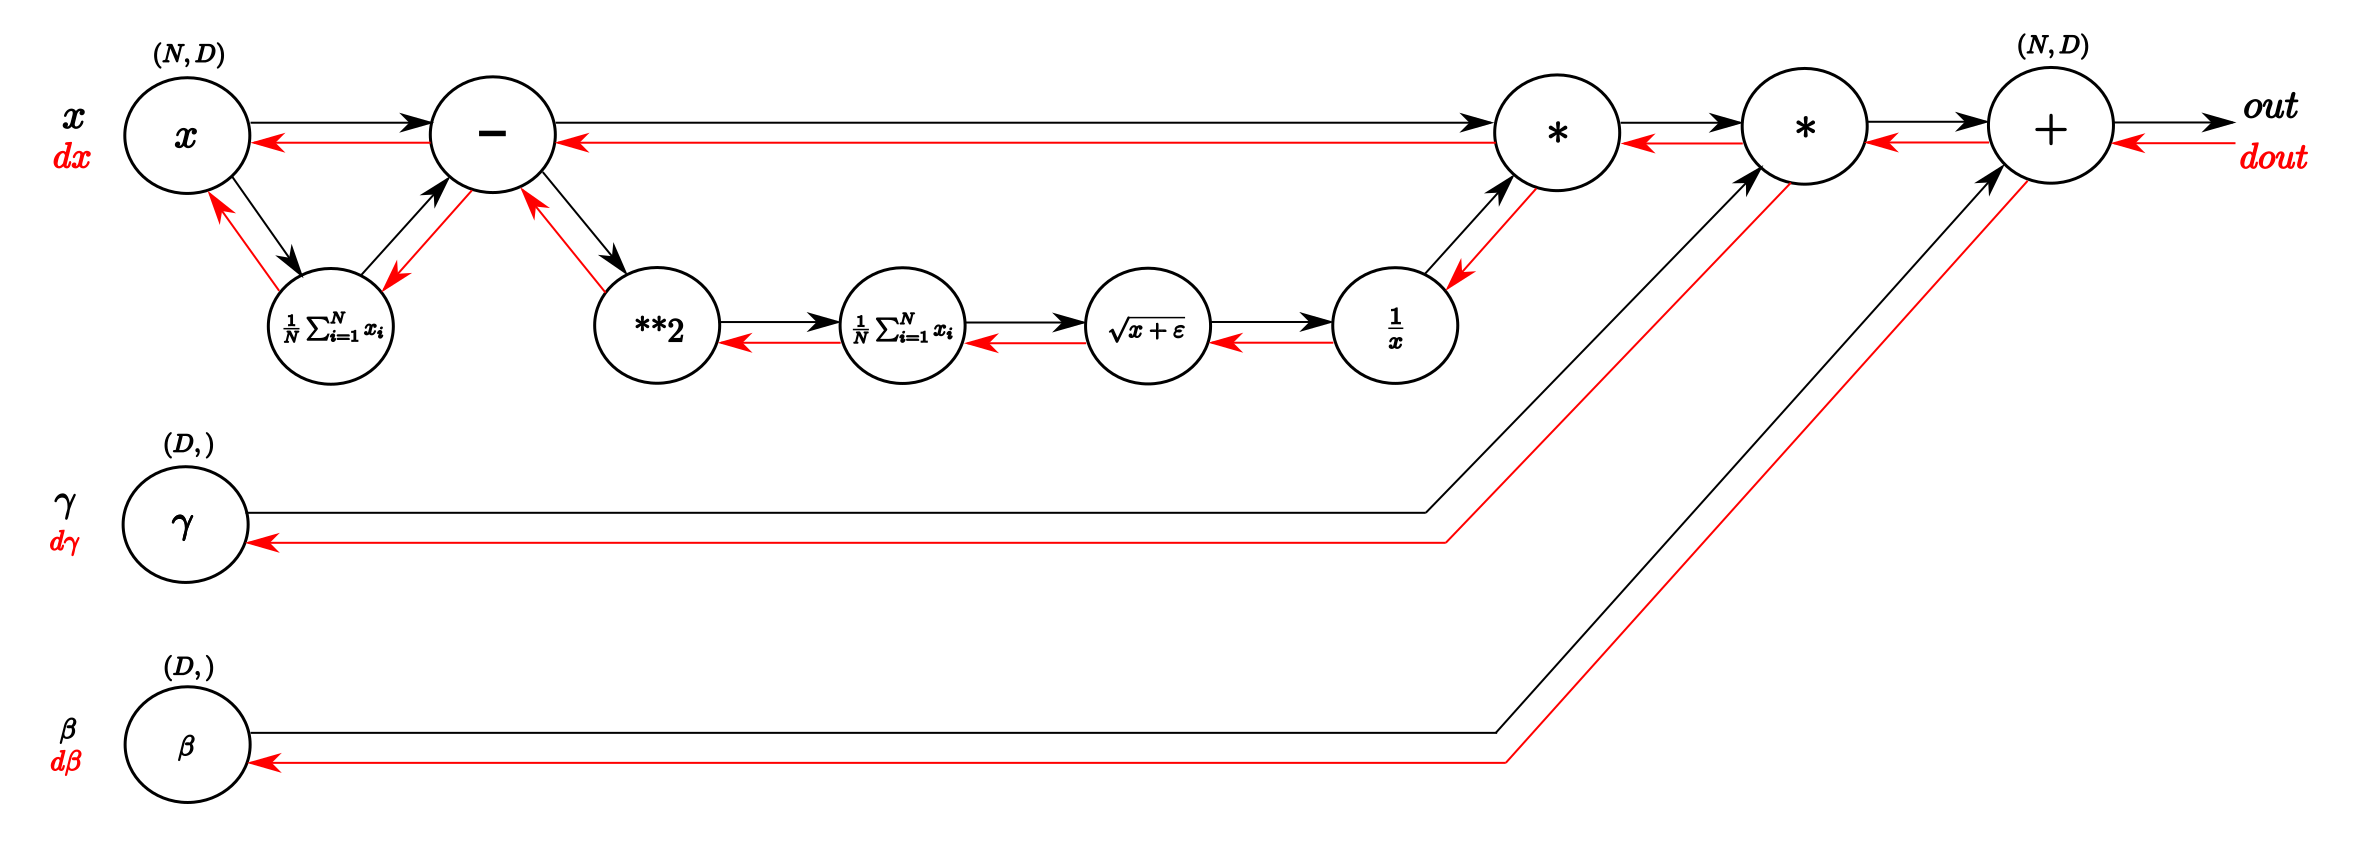

In [13]:
class BatchNormalization:
  """
  http://arxiv.org/abs/1502.03167
  """
  def __init__(self, gamma, beta, momentum=0.9, running_mean=None, running_var=None):
      self.gamma = gamma
      self.beta = beta
      self.momentum = momentum
      self.input_shape = None # Conv 층=4차원, 완전 연결층=2차원

      # 테스트 시 사용하는 평균과 분산(즉, 업데이트 대상)
      self.running_mean = running_mean
      self.running_var = running_var

      # backward 시에 사용하는 중간 데이터
      self.batch_size = None
      self.xc = None
      self.std = None
      self.dgamma = None
      self.dbeta = None

  def forward(self, x, train_flg=True):
      self.input_shape = x.shape
      if x.ndim != 2:
          N, C, H, W = x.shape
          x = x.reshape(N, -1)

      out = self.__forward(x, train_flg)

      return out.reshape(*self.input_shape)


  def __forward(self, x, train_flg):
      if self.running_mean is None:
          N, D = x.shape
          self.running_mean = np.zeros(D)
          self.running_var = np.zeros(D)

      if train_flg:
          mu = x.mean(axis=0)
          xc = x - mu
          var = np.mean(xc**2, axis=0)
          std = np.sqrt(var + 10e-7)
          xn = xc / std

          self.batch_size = x.shape[0]
          self.xc = xc
          self.xn = xn
          self.std = std
          # 평균과 분산의 이동 평균 계산
          self.running_mean = self.momentum * self.running_mean + (1-self.momentum) * mu
          self.running_var = self.momentum * self.running_var + (1-self.momentum) * var
      else:
          # 추론 과정
          xc = x - self.running_mean #채워주세요
          xn = xc / ((np.sqrt(self.running_var + 10e-7))) #채워주세요

      out = self.gamma * xn + self.beta
      return out


  def backward(self, dout):
      if dout.ndim != 2:
          N, C, H, W = dout.shape
          dout = dout.reshape(N, -1)

      dx = self.__backward(dout)

      dx = dx.reshape(*self.input_shape)
      return dx


  def __backward(self, dout):
      dbeta = dout.sum(axis=0)
      dgamma = np.sum(self.xn * dout, axis=0)
      dxn = self.gamma * dout
      dxc = dxn / self.std
      dstd = -np.sum((dxn * self.xc) / (self.std * self.std), axis=0)
      dvar = 0.5 * dstd / self.std
      dxc += (2.0 / self.batch_size) * self.xc * dvar
      dmu = np.sum(dxc, axis=0)
      dx = dxc - dmu / self.batch_size

      self.dgamma = dgamma
      self.dbeta = dbeta

      return dx

**Dropout**

In [14]:
class Dropout:
    """
    http://arxiv.org/abs/1207.0580
    """
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg=True):
        if train_flg:
            self.mask =  np.random.rand(*x.shape)> self.dropout_ratio #채워주세요
            return x * self.mask
        else:
            return x * (1.0 - self.dropout_ratio) #채워주세요

    def backward(self, dout):
        return dout * self.mask

# Training

In [17]:
from torchvision import datasets, transforms

cifar10_train = datasets.MNIST(root='./data', train=True, download=True)
cifar10_test = datasets.MNIST(root='./data', train=False, download=True)

# flatten, normalization
x_train = cifar10_train.data.numpy().reshape(-1, 28 * 28).astype('float32') / 255.0
t_train = cifar10_train.targets
x_test = cifar10_test.data.numpy().reshape(-1, 28 * 28).astype('float32') / 255.0
t_test = cifar10_test.targets

# y one-hot encodeing
n = len(np.unique(t_train))
t_train = np.eye(n)[t_train]
t_test = np.eye(n)[t_test]

print(f'x_train.shape: {x_train.shape}')
print(f't_train.shape: {t_train.shape}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 43.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.16MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.26MB/s]


x_train.shape: (60000, 784)
t_train.shape: (60000, 10)


정규화 기법을 하나씩 적용해보고, 그렇지 않은 경우의 결과를 비교해보세요!

과적합

epoch:0, train acc:0.09, test acc:0.0891
epoch:1, train acc:0.11666666666666667, test acc:0.095
epoch:2, train acc:0.12333333333333334, test acc:0.1021
epoch:3, train acc:0.13333333333333333, test acc:0.1115
epoch:4, train acc:0.13666666666666666, test acc:0.1169
epoch:5, train acc:0.14, test acc:0.1186
epoch:6, train acc:0.13666666666666666, test acc:0.1201
epoch:7, train acc:0.14333333333333334, test acc:0.1237
epoch:8, train acc:0.16333333333333333, test acc:0.1305
epoch:9, train acc:0.18666666666666668, test acc:0.1422
epoch:10, train acc:0.20666666666666667, test acc:0.1528
epoch:11, train acc:0.21, test acc:0.164
epoch:12, train acc:0.23333333333333334, test acc:0.1794
epoch:13, train acc:0.30333333333333334, test acc:0.2083
epoch:14, train acc:0.33666666666666667, test acc:0.2311
epoch:15, train acc:0.3933333333333333, test acc:0.2715
epoch:16, train acc:0.45, test acc:0.3006
epoch:17, train acc:0.48, test acc:0.332
epoch:18, train acc:0.5133333333333333, test acc:0.3526
epoch:1

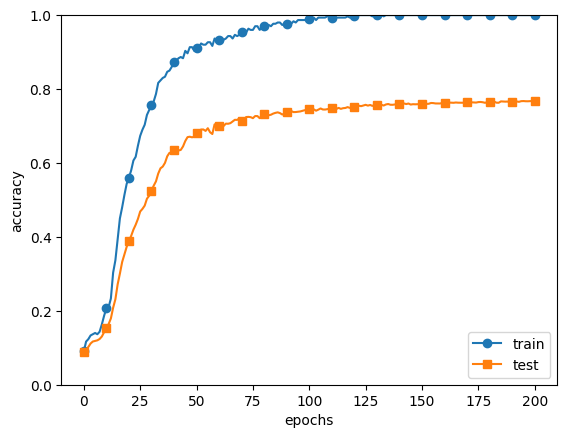

In [18]:
import matplotlib.pyplot as plt


x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0)
# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

weight decay only

epoch:0, train acc:0.09333333333333334, test acc:0.0851
epoch:1, train acc:0.13, test acc:0.1043
epoch:2, train acc:0.16, test acc:0.1206
epoch:3, train acc:0.2, test acc:0.1372
epoch:4, train acc:0.21666666666666667, test acc:0.1546
epoch:5, train acc:0.23666666666666666, test acc:0.1687
epoch:6, train acc:0.2733333333333333, test acc:0.187
epoch:7, train acc:0.2866666666666667, test acc:0.1998
epoch:8, train acc:0.32, test acc:0.208
epoch:9, train acc:0.32666666666666666, test acc:0.2228
epoch:10, train acc:0.3433333333333333, test acc:0.228
epoch:11, train acc:0.3433333333333333, test acc:0.2395
epoch:12, train acc:0.37333333333333335, test acc:0.2493
epoch:13, train acc:0.37666666666666665, test acc:0.2571
epoch:14, train acc:0.38666666666666666, test acc:0.2659
epoch:15, train acc:0.38666666666666666, test acc:0.2696
epoch:16, train acc:0.3933333333333333, test acc:0.277
epoch:17, train acc:0.41333333333333333, test acc:0.2895
epoch:18, train acc:0.41333333333333333, test acc:0.29

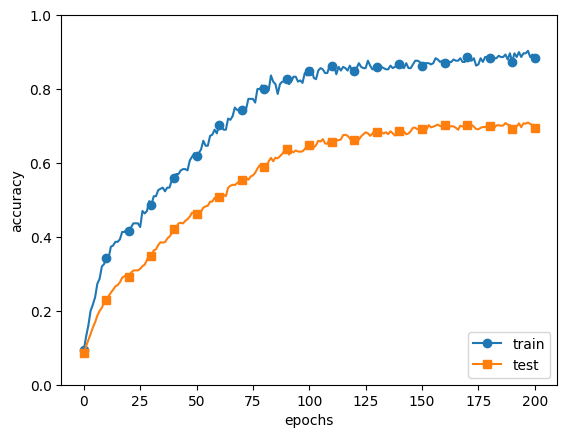

In [19]:
x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0.1)
# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

weight decay only bigger lambda

epoch:0, train acc:0.05333333333333334, test acc:0.0852
epoch:1, train acc:0.10666666666666667, test acc:0.1019
epoch:2, train acc:0.13333333333333333, test acc:0.1134
epoch:3, train acc:0.16666666666666666, test acc:0.1335
epoch:4, train acc:0.20666666666666667, test acc:0.1475
epoch:5, train acc:0.23, test acc:0.1574
epoch:6, train acc:0.2633333333333333, test acc:0.1703
epoch:7, train acc:0.28, test acc:0.1872
epoch:8, train acc:0.2733333333333333, test acc:0.1943
epoch:9, train acc:0.29, test acc:0.2105
epoch:10, train acc:0.30666666666666664, test acc:0.2194
epoch:11, train acc:0.31, test acc:0.2258
epoch:12, train acc:0.31666666666666665, test acc:0.2326
epoch:13, train acc:0.32, test acc:0.2415
epoch:14, train acc:0.3566666666666667, test acc:0.2565
epoch:15, train acc:0.3566666666666667, test acc:0.2536
epoch:16, train acc:0.37, test acc:0.2594
epoch:17, train acc:0.37666666666666665, test acc:0.2596
epoch:18, train acc:0.37333333333333335, test acc:0.2625
epoch:19, train acc:0

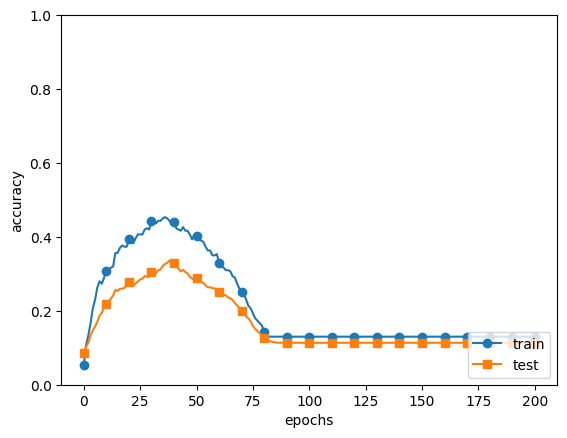

In [20]:
x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0.3)
# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

weight decay with smaller lambda

epoch:0, train acc:0.1, test acc:0.0899
epoch:1, train acc:0.1, test acc:0.098
epoch:2, train acc:0.12, test acc:0.1086
epoch:3, train acc:0.16333333333333333, test acc:0.1186
epoch:4, train acc:0.17, test acc:0.1248
epoch:5, train acc:0.19333333333333333, test acc:0.1357
epoch:6, train acc:0.20333333333333334, test acc:0.1413
epoch:7, train acc:0.21333333333333335, test acc:0.1457
epoch:8, train acc:0.22, test acc:0.152
epoch:9, train acc:0.23, test acc:0.1579
epoch:10, train acc:0.24, test acc:0.164
epoch:11, train acc:0.24666666666666667, test acc:0.1681
epoch:12, train acc:0.27, test acc:0.1778
epoch:13, train acc:0.2833333333333333, test acc:0.1893
epoch:14, train acc:0.2833333333333333, test acc:0.196
epoch:15, train acc:0.2866666666666667, test acc:0.1997
epoch:16, train acc:0.30333333333333334, test acc:0.2045
epoch:17, train acc:0.3, test acc:0.2091
epoch:18, train acc:0.3233333333333333, test acc:0.2271
epoch:19, train acc:0.31333333333333335, test acc:0.2195
epoch:20, train 

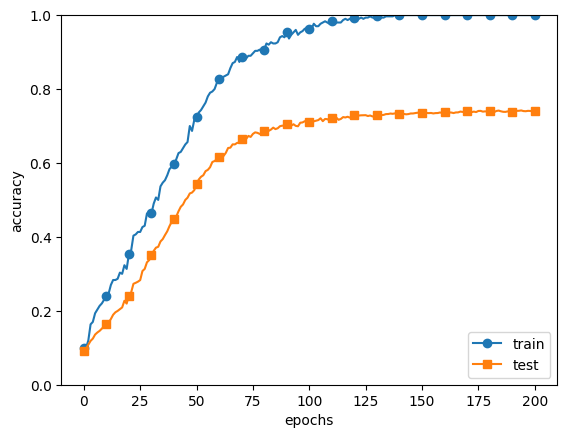

In [21]:
x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0.001)
# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

dropout only

epoch:0, train acc:0.13, test acc:0.1168
epoch:1, train acc:0.12666666666666668, test acc:0.1141
epoch:2, train acc:0.13333333333333333, test acc:0.1164
epoch:3, train acc:0.13333333333333333, test acc:0.1145
epoch:4, train acc:0.14666666666666667, test acc:0.119
epoch:5, train acc:0.12666666666666668, test acc:0.1127
epoch:6, train acc:0.12333333333333334, test acc:0.1116
epoch:7, train acc:0.12666666666666668, test acc:0.1113
epoch:8, train acc:0.13, test acc:0.1121
epoch:9, train acc:0.12333333333333334, test acc:0.1094
epoch:10, train acc:0.12333333333333334, test acc:0.1083
epoch:11, train acc:0.12, test acc:0.1027
epoch:12, train acc:0.12666666666666668, test acc:0.1014
epoch:13, train acc:0.12, test acc:0.1014
epoch:14, train acc:0.11666666666666667, test acc:0.1011
epoch:15, train acc:0.11666666666666667, test acc:0.101
epoch:16, train acc:0.12, test acc:0.1019
epoch:17, train acc:0.12, test acc:0.1017
epoch:18, train acc:0.12, test acc:0.1023
epoch:19, train acc:0.12, test acc

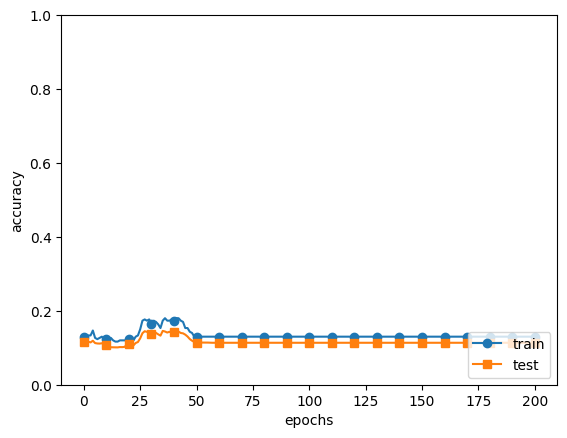

In [22]:
x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                         use_dropout=True, dropout_ration=0.5)
# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

batchnorm only

epoch:0, train acc:0.06333333333333334, test acc:0.0802
epoch:1, train acc:0.06333333333333334, test acc:0.1016
epoch:2, train acc:0.11, test acc:0.1157
epoch:3, train acc:0.13666666666666666, test acc:0.1239
epoch:4, train acc:0.21666666666666667, test acc:0.1465
epoch:5, train acc:0.30333333333333334, test acc:0.1714
epoch:6, train acc:0.4166666666666667, test acc:0.1999
epoch:7, train acc:0.49333333333333335, test acc:0.2205
epoch:8, train acc:0.5833333333333334, test acc:0.2414
epoch:9, train acc:0.6533333333333333, test acc:0.2555
epoch:10, train acc:0.68, test acc:0.2715
epoch:11, train acc:0.7366666666666667, test acc:0.2853
epoch:12, train acc:0.77, test acc:0.3019
epoch:13, train acc:0.8166666666666667, test acc:0.3106
epoch:14, train acc:0.8433333333333334, test acc:0.3232
epoch:15, train acc:0.8633333333333333, test acc:0.3321
epoch:16, train acc:0.8766666666666667, test acc:0.3402
epoch:17, train acc:0.9033333333333333, test acc:0.3489
epoch:18, train acc:0.9233333333333333

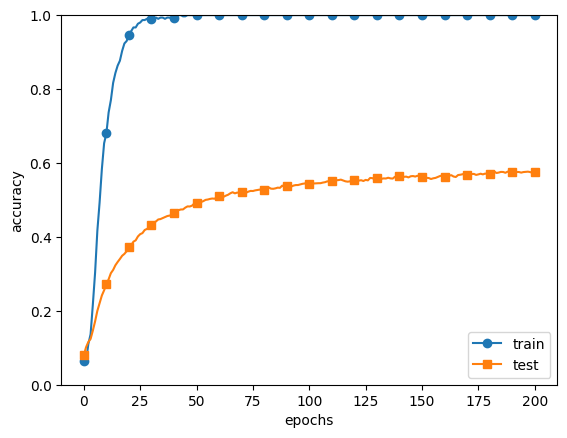

In [23]:
x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        use_batchnorm=True)
# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

All methods

epoch:0, train acc:0.10333333333333333, test acc:0.097
epoch:1, train acc:0.10666666666666667, test acc:0.1011
epoch:2, train acc:0.12, test acc:0.0979
epoch:3, train acc:0.09666666666666666, test acc:0.0978
epoch:4, train acc:0.10333333333333333, test acc:0.1062
epoch:5, train acc:0.10333333333333333, test acc:0.116
epoch:6, train acc:0.1, test acc:0.12
epoch:7, train acc:0.10666666666666667, test acc:0.1227
epoch:8, train acc:0.11666666666666667, test acc:0.1265
epoch:9, train acc:0.12666666666666668, test acc:0.1294
epoch:10, train acc:0.11666666666666667, test acc:0.1276
epoch:11, train acc:0.11666666666666667, test acc:0.1296
epoch:12, train acc:0.12666666666666668, test acc:0.132
epoch:13, train acc:0.12, test acc:0.1283
epoch:14, train acc:0.12, test acc:0.1326
epoch:15, train acc:0.11333333333333333, test acc:0.1316
epoch:16, train acc:0.12333333333333334, test acc:0.1322
epoch:17, train acc:0.12, test acc:0.1349
epoch:18, train acc:0.12666666666666668, test acc:0.1339
epoch:19

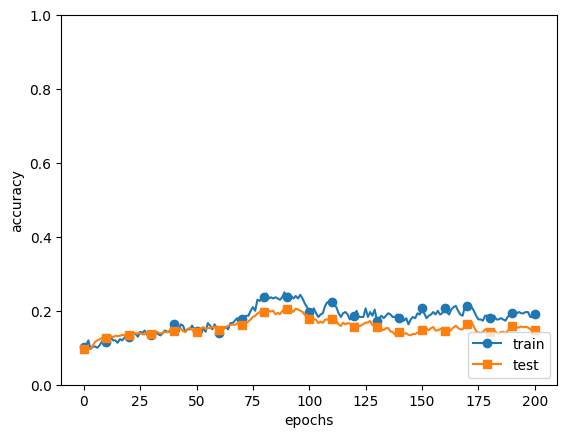

In [24]:
x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0.1, use_dropout=True, dropout_ration = 0.5, use_batchnorm=True)
# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = SGD(lr=0.01)
# optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

All method w. Adam optmizer

epoch:0, train acc:0.07, test acc:0.0974
epoch:1, train acc:0.12333333333333334, test acc:0.115
epoch:2, train acc:0.27666666666666667, test acc:0.2189
epoch:3, train acc:0.17, test acc:0.1366
epoch:4, train acc:0.15666666666666668, test acc:0.1479
epoch:5, train acc:0.13, test acc:0.1163
epoch:6, train acc:0.22333333333333333, test acc:0.1929
epoch:7, train acc:0.19666666666666666, test acc:0.1644
epoch:8, train acc:0.17333333333333334, test acc:0.14
epoch:9, train acc:0.16666666666666666, test acc:0.1305
epoch:10, train acc:0.18666666666666668, test acc:0.1607
epoch:11, train acc:0.32, test acc:0.2402
epoch:12, train acc:0.38333333333333336, test acc:0.2815
epoch:13, train acc:0.4033333333333333, test acc:0.2982
epoch:14, train acc:0.3933333333333333, test acc:0.2921
epoch:15, train acc:0.37666666666666665, test acc:0.3033
epoch:16, train acc:0.41333333333333333, test acc:0.3263
epoch:17, train acc:0.43666666666666665, test acc:0.3506
epoch:18, train acc:0.45666666666666667, test acc

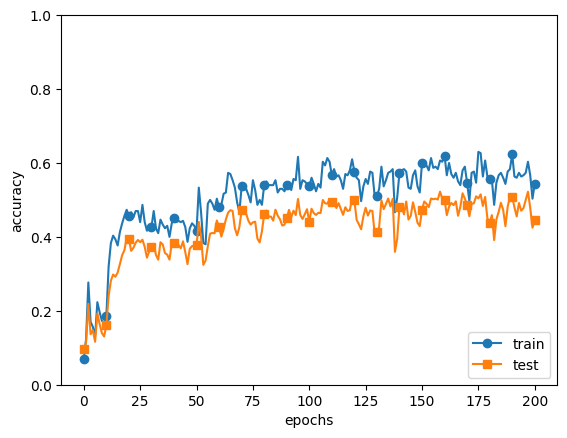

In [25]:
x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0.1, use_dropout=True, dropout_ration = 0.5, use_batchnorm=True)
# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

weight decay only w. Adam optimizer

epoch:0, train acc:0.24333333333333335, test acc:0.206
epoch:1, train acc:0.45, test acc:0.4058
epoch:2, train acc:0.5033333333333333, test acc:0.4332
epoch:3, train acc:0.55, test acc:0.4769
epoch:4, train acc:0.6133333333333333, test acc:0.5219
epoch:5, train acc:0.57, test acc:0.4451
epoch:6, train acc:0.6166666666666667, test acc:0.5173
epoch:7, train acc:0.63, test acc:0.5149
epoch:8, train acc:0.59, test acc:0.4527
epoch:9, train acc:0.63, test acc:0.5242
epoch:10, train acc:0.6466666666666666, test acc:0.5401
epoch:11, train acc:0.5533333333333333, test acc:0.438
epoch:12, train acc:0.62, test acc:0.5019
epoch:13, train acc:0.65, test acc:0.5089
epoch:14, train acc:0.6133333333333333, test acc:0.4887
epoch:15, train acc:0.6666666666666666, test acc:0.5408
epoch:16, train acc:0.62, test acc:0.467
epoch:17, train acc:0.5866666666666667, test acc:0.4708
epoch:18, train acc:0.6766666666666666, test acc:0.5641
epoch:19, train acc:0.6266666666666667, test acc:0.5319
epoch:20, train ac

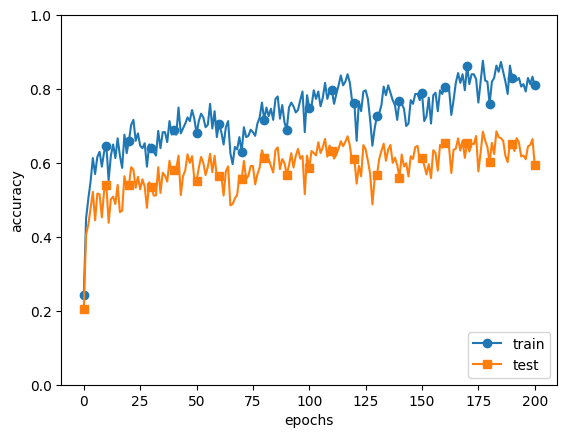

In [26]:
x_train = x_train[:300]   # 적은 데이터를 가정
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=0.1)
# network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
#                         weight_decay_lambda=0.1, use_dropout = False, dropout_ration = 0, use_batchnorm=False)


optimizer = Adam(lr=0.01, beta1=0.9, beta2=0.999)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):   # 과적합 유도
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

Summary



In [27]:
import pandas as pd

results = [
    ["default",                 1.0000, 0.7674],
    ["weight decay(0.1)",       0.8833, 0.6954],
    ["weight decay(0.3)",       0.1300, 0.1135],
    ["weight decay(0.001)",     1.0000, 0.7413],
    ["dropout",                 0.1300, 0.1135],
    ["batch norm",              1.0000, 0.5768],
    ["All method",              0.1900, 0.1490]
]

df = pd.DataFrame(
    results,
    columns=["regularization", "train_acc", "test_acc"]
)

# 일반화 격차
df["gap"] = df["train_acc"] - df["test_acc"]

display(df)

,regularization,train_acc,test_acc,gap
0,default,1.0000,0.7674,0.2326
1,weight decay(0.1),0.8833,0.6954,0.1879
2,weight decay(0.3),0.1300,0.1135,0.0165
3,weight decay(0.001),1.0000,0.7413,0.2587
4,dropout,0.1300,0.1135,0.0165
5,batch norm,1.0000,0.5768,0.4232
6,All method,0.1900,0.1490,0.0410


해석.
weight decay 0.1은 적절하게 오버피팅 문제를 해결했지만 0.001의 작은 람다를 사용하였더니 gap이 줄어들지 않았고,반대로 0.3의 큰 람다로 페널티가 너무 크면 두 accuracy의 갭은 줄어들지만 accuracy 자체가 너무 낮아 제대로 학습했다고 판단하기 어렵다. 즉 weight decay는 lambda = 0.1이 제일 적합하다.
dropout method도 전반적으로 낮은 accuracy로 학습이 제대로 일어나지 않았고, batch norm은 과적합을 해결하지 못했다.모든 방법을 다 사용해도 기대보단 낮은 accuracy를 보여주었다.

weight decay, lambda = 0.1에서 optimizer변화

In [28]:
results2 = [
    ["SGD",        0.8833, 0.6954],
    ["ADAM",       0.8100, 0.5940],
]

df2 = pd.DataFrame(
    results2,
    columns=["optimizer", "train_acc", "test_acc"]
)

# 일반화 격차
df2["gap"] = df2["train_acc"] - df2["test_acc"]

display(df2)

,optimizer,train_acc,test_acc,gap
0,SGD,0.8833,0.6954,0.1879
1,ADAM,0.8100,0.5940,0.2160


all method 에서 optimizer변화

In [29]:
results3 = [
    ["SGD",        0.1366, 0.1185],
    ["ADAM",       0.5700, 0.4694],
]

df3 = pd.DataFrame(
    results3,
    columns=["optimizer", "train_acc", "test_acc"]
)

# 일반화 격차
df3["gap"] = df3["train_acc"] - df3["test_acc"]

display(df3)

,optimizer,train_acc,test_acc,gap
0,SGD,0.1366,0.1185,0.0181
1,ADAM,0.5700,0.4694,0.1006


해석.
weight decay lambda=0.1에서는 어떤 optimizer를 사용하더라도 오버피팅 없이 잘 학습되었고, 갭을 살펴보면 SGD에서 조금 더 잘 학습된 것을 알 수 있다. 그러나 모든 방식을 적용한 모델에서는 비록 SGD의 gap이 더 작을지라도 SGD는 낮은 accuracy로 잘 학습되지 않은 반면 ADAM이 잘 학습되었다고 판단한다.